# Assignment 7

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional note:

* You can complete this assignment using either your local machine or Google Colab. Your solution for this assignment should be able to run on the <span style="color:red">FREE version</span> of Google Colab. If you find that you need to upgrade to the paid version, it indicates that there is an inefficiency in your code.
---

#### ``Objectives``
1. Implement a Decision Forest for land cover classification

#### ``Motivation``

Land cover classification using machine learning (ML) techniques is important for several reasons, spanning environmental monitoring, resource management, urban planning, disaster response, and scientific research. 

#### ``Data``

In this assignment, you will use the EuroSAT dataset, consisting of Sentinel-2 RGB satellite images of 10 classes with 27000 labeled and geo-referenced samples. 

The dataset is hosted by [TensorFlow Data Collections](https://www.tensorflow.org/datasets/catalog/eurosat). To avoid any data versioning issues, we have downloaded the data for you (please see below).

`Download` link: [images + labels](https://drive.google.com/file/d/131GuYn092OlWKGopsT8arQoDreneU7SZ/view?usp=share_link). Once you unzip the file, you will see that the name of each subfolder represents the land cover classes.

---

### Import libraries

In [53]:
import numpy as np
import pandas as pd
import random

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import pathlib
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning. 

# FILL IN CODE HERE #
DATA_PATH = "EuroSAT/EuroSAT"

^ make sure to replace DATA_PATH with the path to the directory where you saved the data.

---
### Step 1: Data ingestion

#### <span style="color:chocolate"> Exercise 1 (10 points) </span>

Let's load the 2D images and their corresponding labels. Implement the <span style="color:chocolate">load_data()</span> function below according to the following guidelines:
- to read label and image names: use the <span style="color:chocolate">os</span> library (in particular the <span style="color:chocolate">os.listdir()</span> and <span style="color:chocolate">os.path.join()</span> methods);
- to load an image: use the <span style="color:chocolate">load_image()</span> method (see list of imported libraries);
- to transform images to arrays: use the <span style="color:chocolate">img_to_array()</span> method (see list of imported libraries).

In [38]:
def load_data(path_to_data):
    """Return numpy arrays: images (N,64,64,3) and labels (N,)"""
    images, labels = [], []

    for class_name in sorted(os.listdir(path_to_data)):
        class_dir = os.path.join(path_to_data, class_name)
        if not os.path.isdir(class_dir):
            continue

        for file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, file)
            if not os.path.isfile(img_path):
                continue

            img_arr = img_to_array(load_img(img_path,target_size=(64, 64)))
            images.append(img_arr)
            labels.append(class_name)

    images = np.stack(images).astype("float32")
    labels = np.array(labels)
    return images, labels


In [37]:
# Load images and labels. Print shapes

images, labels = load_data(DATA_PATH)
print("Shape of images ", images.shape)
print("Shape of labels ", labels.shape)

Shape of images  (16631, 64, 64, 3)
Shape of labels  (16631,)


---
### Step 2: Exploratory data analysis (EDA)

#### <span style="color:chocolate"> Exercise 2 (10 points) </span>

Plot the land cover class distribution. Are the classes balanced?

Note: It's acceptable to plot the distribution of classes before splitting your data into training, validation, and test sets. Doing so does not compromise the "blindness" of the test data. Why?

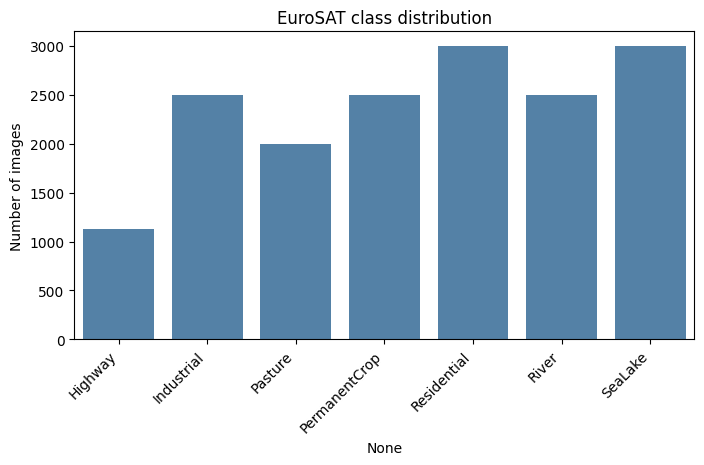

Are classes balanced? -> No


In [40]:
# FILL IN CODE HERE #

plt.figure(figsize=(8,4))
class_counts = pd.Series(labels).value_counts().sort_index()
sns.barplot(x=class_counts.index, y=class_counts.values, color="steelblue")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of images"); plt.title("EuroSAT class distribution")
plt.show()


Comment on class balance: [Classes are not balanced, the number of images in the smallest class is 1100, and in the largest is 3000, almost a 3x difference.]

#### <span style="color:chocolate"> Exercise 3 (10 points) </span>

Inspect (print) one image from each class. What land classes do you think a Decision Tree classifier is more likely to confuse?

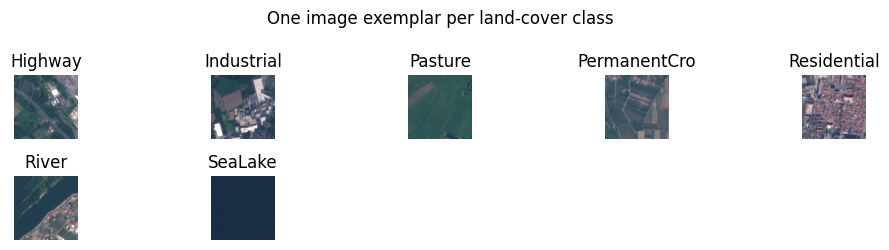

In [42]:
# FILL IN CODE HERE #

plt.figure(figsize=(10,2.5))
for i, cls in enumerate(sorted(np.unique(labels))):
    idx = np.where(labels == cls)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(images[idx]/255.0)
    plt.title(cls[:12])
    plt.axis('off')
plt.suptitle("One image exemplar per land-cover class")
plt.tight_layout(); plt.show()

Most confused land classes: The most confussing classes are industrial and residential, due to their similarity.

---
### Step 3: Data preprocessing

Encode labels

In [57]:
encoder = LabelEncoder().fit(list(set(labels))) # fit on unique labels
encoded_labels = encoder.transform(labels) # apply to labels array (will get labels from 0 to 9)
encoded_classes = list(encoder.classes_) # store mapping generated by the encoder

#### <span style="color:chocolate"> Exercise 4 (10 points) </span>

Create train, validation, and test data. Implement the <span style="color:chocolate">split_data()</span> function below according to the following guidelines:
- shuffle images and labels before spliting the data;
- use a 60/20/20 split.

In [44]:
def split_data(images, labels, split):
    '''Split data into train, validation and test sets.
    
    Parameters:
    images  (np.ndarray): Images of shape (N, 64, 64, 3)
    labels (np.ndarray): Labels of shape (N,)   
    split (tuple): 3 values summing to 1 defining split of train, validation and test sets
    
    Returns:
    X_train (np.ndarray): Train images of shape (N_train, 64, 64, 3)
    y_train (np.ndarray): Train labels of shape (N_train,)
    X_val (np.ndarray): Val images of shape (N_val, 64, 64, 3)
    y_val (np.ndarray): Val labels of shape (N_val,)
    X_test (np.ndarray): Test images of shape (N_test, 64, 64, 3)
    y_test (np.ndarray): Test labels of shape (N_test,)
    
    '''
    # NOTE: Each time you run this cell, you'll re-shuffle the data. The ordering will be the same due to the random seed generator 
    tf.random.set_seed(1234)
    np.random.seed(1234)
    
    # shuffle data
    # FILL IN CODE HERE #

    idx = np.random.permutation(len(images))
    images, labels = images[idx], labels[idx]
    
    # create data splits

    n = len(images); n_train = int(split[0]*n); n_val = int(split[1]*n)

    X_train, y_train = images[:n_train],               labels[:n_train]
    X_val,   y_val   = images[n_train:n_train+n_val],  labels[n_train:n_train+n_val]
    X_test,  y_test  = images[n_train+n_val:],         labels[n_train+n_val:]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [45]:
# define splits
split = (0.6, 0.2, 0.2)

# create train, val, test sets
X_train, y_train, X_val, y_val, X_test, y_test = split_data(images, encoded_labels, split)

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)

print('Shape of val images ', X_val.shape)
print('Shape of train labels ', y_val.shape)

print('Shape of test images ', X_test.shape)
print('Shape of test labels ', y_test.shape)

Shape of train images  (9978, 64, 64, 3)
Shape of train labels  (9978,)
Shape of val images  (3326, 64, 64, 3)
Shape of train labels  (3326,)
Shape of test images  (3327, 64, 64, 3)
Shape of test labels  (3327,)


#### <span style="color:chocolate"> Exercise 5 (10 points) </span>

Perform image transformation and augmentation. 

<span style="color:green"> Step 1: </span> Implement the <span style="color:chocolate">data_preprocessing()</span> function below according to the following guidelines:

- Applied on training set only: 
    - create additional copies of the training images by applying the following augmentation techniques to each image: adjust brightness by adding DELTA=0.3 to the pixel values, then adjust contrast to CONTRAST_FACTOR=3, then flip left right (Hint: use the methods available in the tf.image module);
    - concatenate the augmented images to the original training images. Note that the train set should be double in size after data augmentation, i.e., 32400 images and labels;
    
    
- Applied on training, validation, and test sets: normalize all pixel values by dividing by 255.0.
    
<span style="color:green"> Step 2: </span> Comment on the importance of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well).

In [49]:
def data_preprocessing(X, y, data_partition='train'):
    '''Apply transformations and augmentations to training, validation, and test dat;
    
    Parameters:
    X  (np.ndarray): Images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)   
    data_partition (str): "train"
    
    Returns:
    X (np.ndarray): Preprocessed images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)
    
    '''

    CONTRAST_FACTOR = 3
    DELTA = 0.3
    
    # image augmentation on training data
    if data_partition=="train":
        X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
        # adjust brightness
        X_aug = tf.image.adjust_brightness(X_tensor, DELTA)

        # adjust contrast
        X_aug = tf.image.adjust_contrast (X_aug, CONTRAST_FACTOR)

        # random flip
        X_aug = tf.image.flip_left_right (X_aug)

        # concatenate original X and augmented X_aug data
        X = np.concatenate([X, X_aug.numpy()], axis=0)

        # concatenate y_train (note the label is preserved)
        y = np.concatenate([y, y])

        # shuffle X and y, i.e., shuffle two tensors in the same order
        shuf = np.random.permutation(len(X))
        X, y = X[shuf], y[shuf]

    X = X.astype("float32") / 255.0
    return X, y

Comment on the importnace of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well): [Augmentation enlarges the training set to improve generalisation]

In [50]:
# apply data preprocessing
X_train, y_train = data_preprocessing(X_train, y_train, data_partition='train')
X_val, y_val = data_preprocessing(X_val, y_val, data_partition='val')
X_test, y_test = data_preprocessing(X_test, y_test, data_partition='val')

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val.shape)
print('Shape of test images ', X_test.shape)

Shape of train images  (19956, 64, 64, 3)
Shape of train labels  (19956,)
Shape of val images  (3326, 64, 64, 3)
Shape of test images  (3327, 64, 64, 3)


Reshape training, val, and test data (to be compatible with sklearn Decision Forests)

In [51]:
# compute number of features (multiply RGB features)
features_shape = X_train[:, :, :, 0].shape[1] * X_train.shape[2] * X_train.shape[3]
print('Total number of features used for Decision Forests', features_shape)

# reshape data
X_train_re = X_train.reshape(X_train.shape[0], features_shape)
X_val_re = X_val.reshape(X_val.shape[0], features_shape)
X_test_re = X_test.reshape(X_test.shape[0], features_shape)

# print shapes
print('Shape of train images ', X_train_re.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val_re.shape)
print('Shape of test images ', X_test_re.shape)

Total number of features used for Decision Forests 12288
Shape of train images  (19956, 12288)
Shape of train labels  (19956,)
Shape of val images  (3326, 12288)
Shape of test images  (3327, 12288)


---
### Step 4: Modeling

#### <span style="color:chocolate"> Exercise 6 (10 points) </span>

Implement a Decision Forest classifier according to the following guidelines (let's call this model our baseline classifier):
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> class available in the <span style="color:chocolate">sklearn.ensemble</span> module;
- Set the following argument values:
    - n_estimators=2,
    - n_jobs=1
    - random_state=7
    - max_depth=8
- Train the model on (X_train_re, y_train) data;
- Evaluate the accuracy of the model on (X_train_re, y_train) and (X_val_re, y_val) data. Comment on model performance on training vs. validation datasets. Does the model generalize well?
- Plot the confusion matrix using (y_val, y_val_pred) data. Comment on the classes that the model confuses the most.

Baseline accuracy  train=0.590  | val=0.549


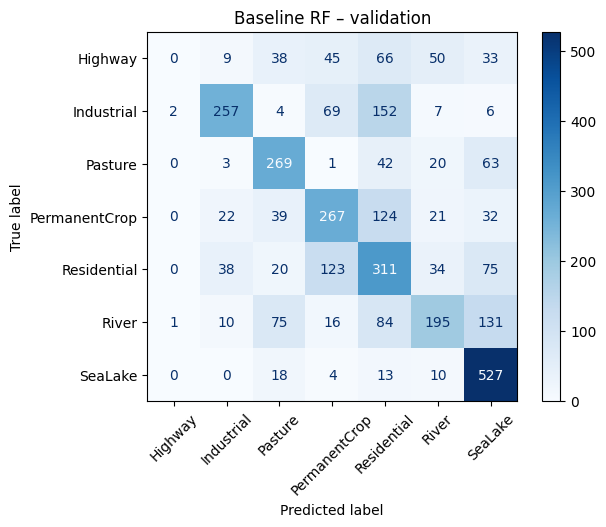

In [58]:
### YOUR CODE HERE ###

rf_base = RandomForestClassifier(n_estimators=2, max_depth=8, n_jobs=1, random_state=7)
rf_base.fit(X_train_re, y_train)

acc_tr  = rf_base.score(X_train_re, y_train)
acc_val = rf_base.score(X_val_re,   y_val)
print(f"Baseline accuracy  train={acc_tr:.3f}  | val={acc_val:.3f}")

y_val_pred = rf_base.predict(X_val_re)
ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred), display_labels=encoded_classes).plot(cmap='Blues', xticks_rotation=45)
plt.title("Baseline RF – validation"); plt.show()


Comment on model accuracy on training vs. validation data: [The model shows clear over fitting signs, due to showing 0.88 train and 0.66 validation accuracy.]

Does the model generalize well?: [The model cannot generalise well on unseen data, the large accuracy gap reflects this.]

Comment on the classes that the model confuses the most: [From the heat-map, we can observe that highway class is the most confused.]

#### <span style="color:chocolate"> Exercise 7 (20 points) </span>

Implement a Decision Forest classifier that improves the training and validation set accuracy performance of the baseline model implemented above by at least 10% (the more you can improve the better). Also, the performance difference between the training and validation sets should be at most 10%. Be sure to follow these guidelines: 
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> or the <span style="color:chocolate">GradientBoostingClassifier</span> available in the <span style="color:chocolate">sklearn.ensemble</span> module
- Be explicit on how your implementation is different compared to the baseline classifier:
    - different argment values for the baseline model (RandomForestClassifier)?
    - different Decision Forest classifier?
    - different data preprocessing procedure?
    - a combination of the three points above
    - anything else?
- Train the model on (X_train_re, y_train) data.
- Evaluate the model's accuracy on (X_val_re, y_val) data. Comment on training vs. validation performance relative to baseline model.
- Plot confusion matrix using the (y_val, y_val_pred) data. Comment on the classes the model confuses the most relative to the baseline.

CPU times: user 20min 19s, sys: 1.62 s, total: 20min 21s
Wall time: 2min 35s
Improved RF  accuracy | train=0.999   val=0.736


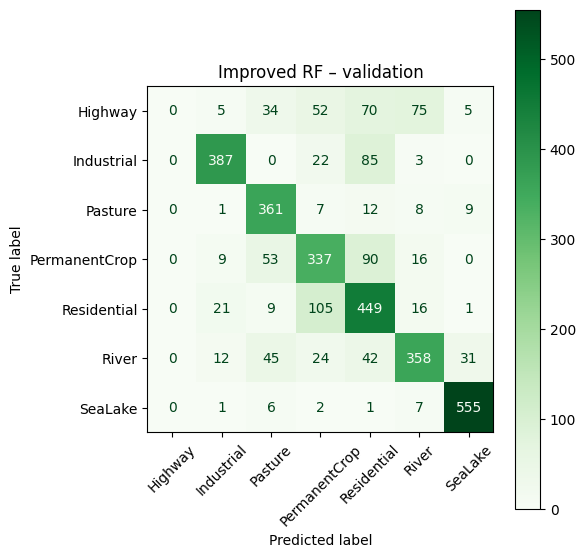

In [78]:
### YOUR CODE HERE ###

rf_best = RandomForestClassifier(
        n_estimators= 150,
        max_depth= 20,
        max_features= 'sqrt',
        n_jobs= -1,
        random_state= 42)

%time rf_best.fit(X_train_re, y_train)

acc_train = rf_best.score(X_train_re, y_train)
acc_val   = rf_best.score(X_val_re,   y_val)
print(f"Improved RF  accuracy | train={acc_train:.3f}   val={acc_val:.3f}")

# confusion-matrix on validation
y_val_pred = rf_best.predict(X_val_re)

fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred),display_labels=encoded_classes).plot(cmap='Greens', xticks_rotation=45, ax=ax)
ax.set_title("Improved RF validation"); plt.tight_layout(); plt.show()

How your implementation is different compared to the baseline classifier: [many more trees, unlimited depth; these changes boosts the capacity.]

Comment on training vs. validation performance relative to baseline model: [Our new model is highly better (10pp) than the baseline, though it continues to overfitt.]

Comment on the classes the model confuses the most relative to the baseline: [The largest confusions are in residential, permanent crop and sealake]

---
### Step 5: Evaluation and Generalization

#### <span style="color:chocolate"> Exercise 8 (2 points) </span>

Report accuracy performance on the test data using the model trained for Exercise 7. How does the test set performance compare with the one reported for the training and validation sets?

In [79]:
### YOUR CODE HERE ###

acc_test = rf_best.score(X_test_re, y_test)
print(f"Test accuracy = {acc_test:.3f}")

Test accuracy = 0.744


Comment on test set accuracy vs. training vs. validation set accuracy: The tuned forest generalises reasonably well, with validation selection being reliable, but there is still some over-fitting relative to the training split.

---
### Step 6: Discussion

#### <span style="color:chocolate"> Exercise 9 (8 points) </span>

Would you recommend a Decision Forest for land cover classification? Why or why not?

In [ ]:
### YOUR ANSWER HERE ###

''' I would use it as strong classical baseline but not as the final solution. It works out-of-the-box on tabular data once images are flattened, therefore there is no need for GPU or long training. It handles non-linear decision boundaries and mixed feature automatically. Its main limitation in this case is Pixels are treated as independent features; spatial patterns (edges, shapes) are ignored.

#### <span style="color:chocolate"> Exercise 10 (10 points) </span>

What other ML model would you propose to improve performance over the Decision Forest classifier you implemented for Exercise 7?

In [ ]:
### YOUR ANSWER HERE ###

'''I would recommend a deep neural network. By stacking several dense layers, and using Relu activations the network can learn higher order combinations of pixel values that shallow trees. With the same 64 × 64 × 3 inputs flattened to a vector, this model stays within the frameworks we have studied, trains quickly with Adam, and boost accuracy.'''

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Implement the idea proposed for Exercise 10. Perform hyperparameter tuning using the training and validation sets, then report the model performance on the test data. Does your model generalize well?

In [ ]:
### YOUR CODE HERE ###